正在训练 XGBoost 模型...


D:\anaconda\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:38:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



模型评估结果
Accuracy (准确率): 0.7422

Classification Report (分类报告):
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       160
           1       0.55      0.48      0.52        66
           2       0.69      0.66      0.67        61

    accuracy                           0.74       287
   macro avg       0.69      0.67      0.68       287
weighted avg       0.73      0.74      0.74       287

ROC AUC (Macro, OvR): 0.8637


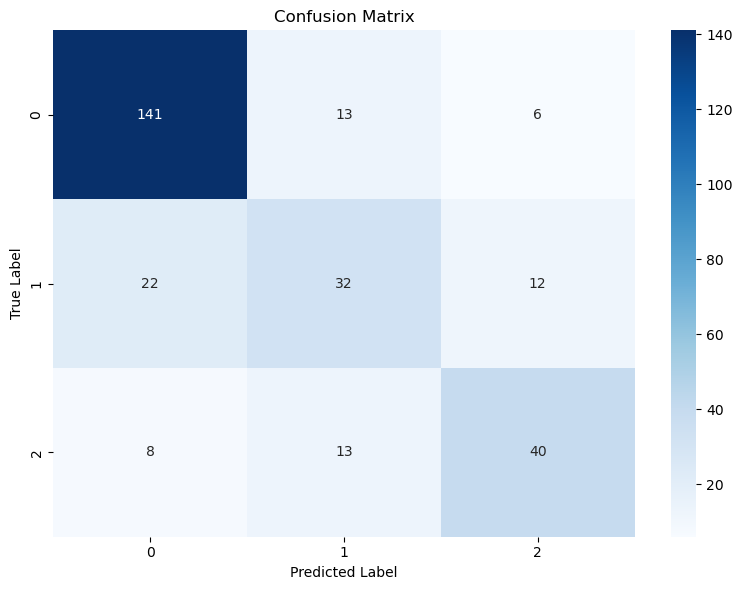

混淆矩阵已保存为 'confusion_matrix.png'


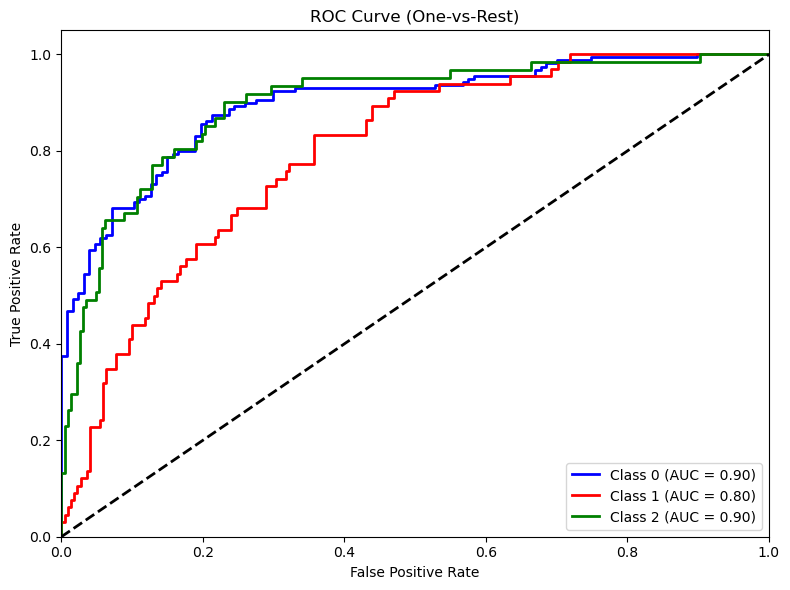

ROC 曲线已保存为 'roc_curve.png'


In [20]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelBinarizer

# ==========================================
# 1. 数据读取与预处理
# ==========================================
# 读取数据
file_path = "筛选后的特征.xlsx"  # 请确保文件在当前目录下
df = pd.read_excel(file_path)

# 剔除无关列（如样本名称）
if 'name' in df.columns:
    df = df.drop(columns=['name'])

# 处理缺失值（直接删除或填充，这里采用删除）
df = df.dropna()

# 分离特征 (X) 和 标签 (y)
X = df.drop(columns=['target'])
y = df['target']

# 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 2. 构建与训练 XGBoost 模型
# ==========================================
# 初始化模型
# 对于多分类问题，XGBoost 会自动推断 num_class，但显式指定更稳健
model = xgb.XGBClassifier(
    n_estimators=100,       # 树的数量
    learning_rate=0.3,      # 学习率
    max_depth=20,            # 树深
    objective='multi:softprob', # 多分类目标函数
    eval_metric='mlogloss',     # 多分类评估指标
    use_label_encoder=False,
    random_state=42
)

# 训练模型
print("正在训练 XGBoost 模型...")
model.fit(X_train, y_train)

# ==========================================
# 3. 模型预测与评价指标
# ==========================================
# 预测标签和概率
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("\n" + "="*50)
print("模型评估结果")
print("="*50)

# 3.1 基础指标 (Accuracy)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (准确率): {acc:.4f}")

# 3.2 详细分类报告 (Precision, Recall, F1-score)
print("\nClassification Report (分类报告):")
print(classification_report(y_test, y_pred))

# 3.3 多分类 ROC-AUC 计算 (One-vs-Rest)
# 需要将标签二值化才能计算多分类 AUC
lb = LabelBinarizer()
lb.fit(y_test)
y_test_bin = lb.transform(y_test)
n_classes = y_test_bin.shape[1]

# 计算宏平均 AUC
roc_auc_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro, OvR): {roc_auc_macro:.4f}")

# 3.4 绘制混淆矩阵 (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("混淆矩阵已保存为 'confusion_matrix.png'")

# 3.5 绘制多分类 ROC 曲线 (可选)
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
             label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("ROC 曲线已保存为 'roc_curve.png'")


正在进行特征归一化...

[验证集 (Validation)] 详细评价结果 (归一化后):
  - Accuracy:  0.7442
  - Precision: 0.7275
  - Recall:    0.7442
  - F1-Score:  0.7302
  - ROC AUC:   0.8720

[测试集 (Test)] 详细评价结果 (归一化后):
  - Accuracy:  0.7442
  - Precision: 0.7403
  - Recall:    0.7442
  - F1-Score:  0.7412
  - ROC AUC:   0.8819


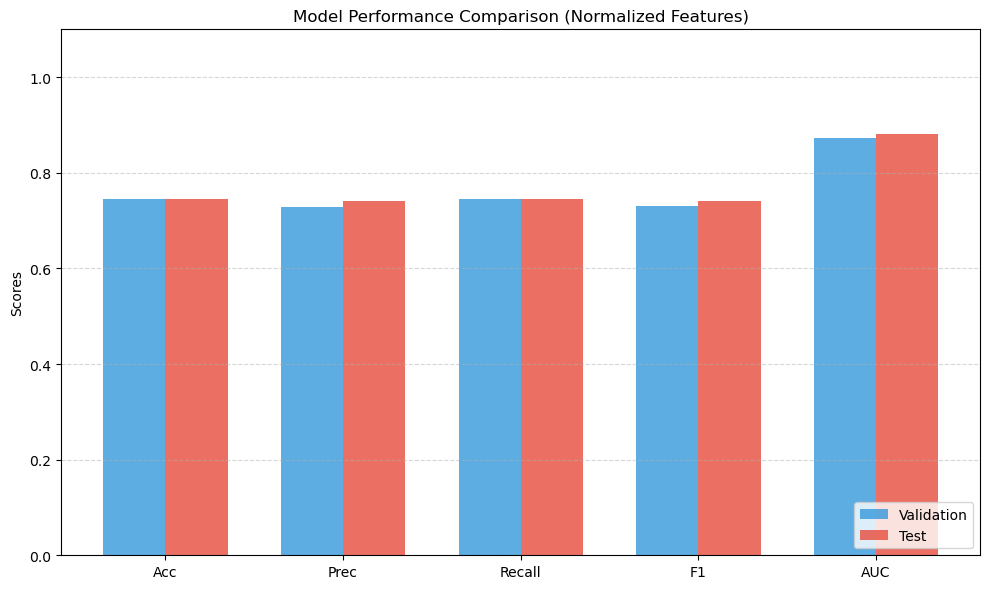

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # 引入标准化工具
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

# ==========================================
# 1. 数据读取与预处理
# ==========================================
file_path = "筛选后的特征.xlsx" 
df = pd.read_excel(file_path)

if 'name' in df.columns:
    df = df.drop(columns=['name'])
df = df.dropna()

X = df.drop(columns=['target'])
y = df['target']

# --- 数据集三阶段划分 ---
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# ==========================================
# 2. 特征归一化 (Standardization)
# ==========================================
# 科学做法：仅在训练集上 fit，然后应用到验证集和测试集，防止信息泄露
scaler = StandardScaler()

print("正在进行特征归一化...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 将归一化后的数据转回 DataFrame 格式，方便模型记录特征名
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# ==========================================
# 3. 构建高评分模型并训练
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42
)

# 使用归一化后的数据训练
model.fit(
    X_train_scaled, y_train, 
    eval_set=[(X_val_scaled, y_val)], 
    verbose=False
)

# ==========================================
# 4. 全指标评估函数
# ==========================================
def print_full_metrics(X_data, y_true, dataset_name):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    
    print(f"\n[{dataset_name}] 详细评价结果 (归一化后):")
    print(f"  - Accuracy:  {acc:.4f}")
    print(f"  - Precision: {prec:.4f}")
    print(f"  - Recall:    {rec:.4f}")
    print(f"  - F1-Score:  {f1:.4f}")
    print(f"  - ROC AUC:   {auc_score:.4f}")
    
    return [acc, prec, rec, f1, auc_score]

# 评价结果
val_results = print_full_metrics(X_val_scaled, y_val, "验证集 (Validation)")
test_results = print_full_metrics(X_test_scaled, y_test, "测试集 (Test)")

# ==========================================
# 5. 可视化指标对比图
# ==========================================
metrics_names = ['Acc', 'Prec', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, val_results, width, label='Validation', color='#3498db', alpha=0.8)
plt.bar(x + width/2, test_results, width, label='Test', color='#e74c3c', alpha=0.8)

plt.ylabel('Scores')
plt.title('Model Performance Comparison (Normalized Features)')
plt.xticks(x, metrics_names)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('normalized_metrics_comparison.png', dpi=300)
plt.show()

In [8]:
X_train_scaled

,ALogp2,nAtom,ATSC3c,ATSC0m,ATSC1p,ATSC8s,AATSC6m,AATSC8m,AATSC4v,AATSC4i,GATS4i,VR2_DzZ,VE1_Dzm,maxssCH2,IC3,MDEC-22
0,-0.049621,-0.204075,1.509976,0.136355,0.513841,-0.250236,1.810234,0.461165,0.146343,-0.883003,-1.216658,-0.044745,-0.797168,-0.253346,1.311377,-0.475260
1,-0.790138,1.209906,0.052979,0.152366,1.119335,-0.087622,-0.569461,0.452859,0.328074,0.499369,0.237158,-0.044600,-0.395381,0.849662,0.210910,-2.421527
2,-0.674244,-1.451705,-0.409638,-1.112000,0.476287,-0.519472,0.193427,-1.703167,-0.899591,-0.298316,-0.318349,-0.046732,0.346528,0.215668,-0.314751,-0.903206
3,1.594873,0.378153,-0.707985,0.804514,0.315805,-2.178395,1.936471,-0.784437,0.371333,-0.140396,-0.823378,-0.046441,1.033887,0.303374,-1.386518,-0.262355
4,-0.688290,0.294978,0.031295,-0.139640,0.153580,-0.433153,0.159220,-0.505038,-0.475844,0.028574,0.794734,-0.045694,-0.193425,0.584921,0.780426,0.464177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.145676,-0.120899,0.385850,-0.403949,-1.778463,-0.186178,0.081113,-0.480021,0.760546,0.749677,0.135986,-0.044869,2.296005,0.628331,-0.308079,0.292822
997,-0.461560,-1.119003,-0.042465,-0.789391,-0.035726,0.676924,0.677899,-1.036185,-2.750570,-0.921110,1.024612,-0.045963,-0.891479,-1.937430,-0.681607,-0.272963
998,2.279138,0.960380,-2.129990,1.158735,0.170850,5.004235,2.374852,2.379488,0.223760,1.305282,-0.959490,-0.044373,-1.361521,-0.487505,2.269817,-0.349421
999,-0.550491,1.459432,0.415341,0.934268,-0.730502,-1.006292,-0.419150,-0.708694,0.282875,0.132513,-0.480510,-0.046321,0.115641,0.745851,-0.526203,0.545997



正在进行 SHAP 解释分析...


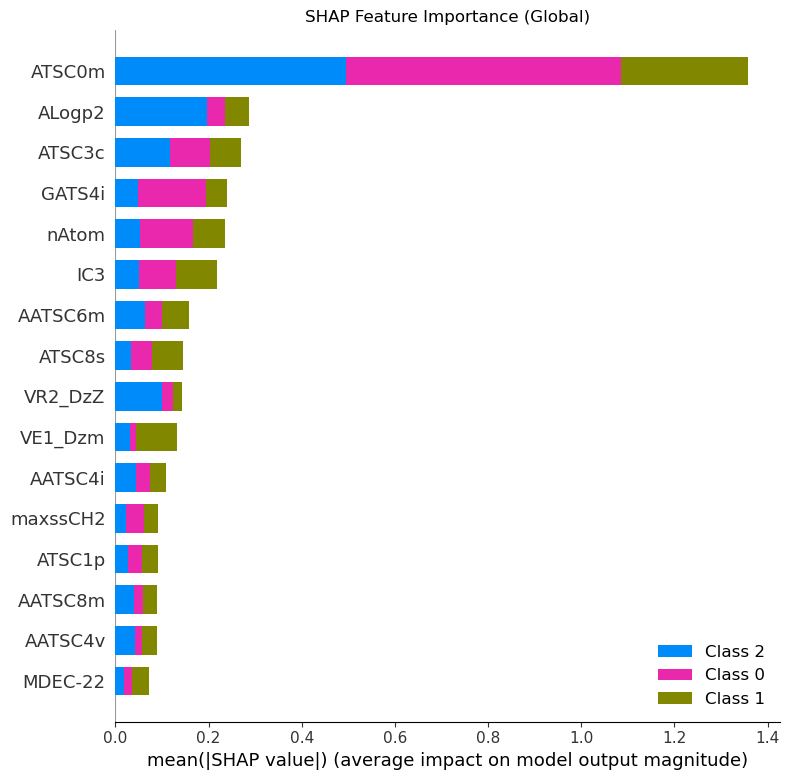

SHAP 综合柱状图已保存为 'shap_summary_bar.png'
正在生成类别 Low(0) 的分析图...


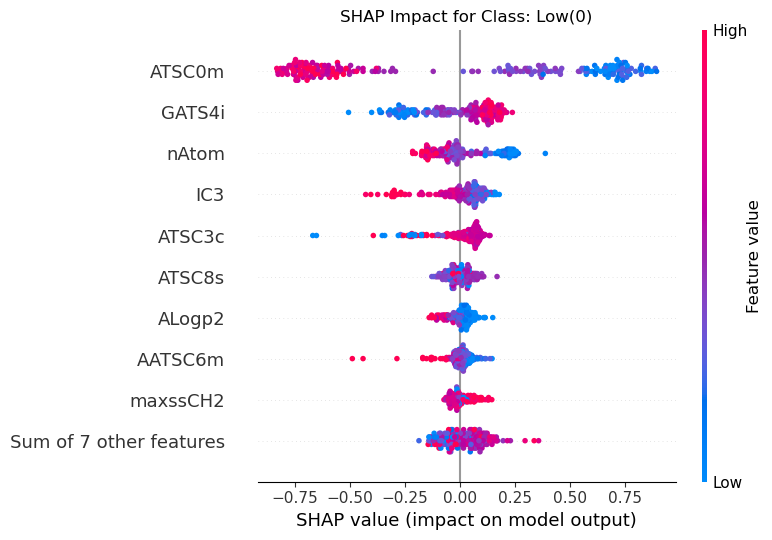

正在生成类别 Medium(1) 的分析图...


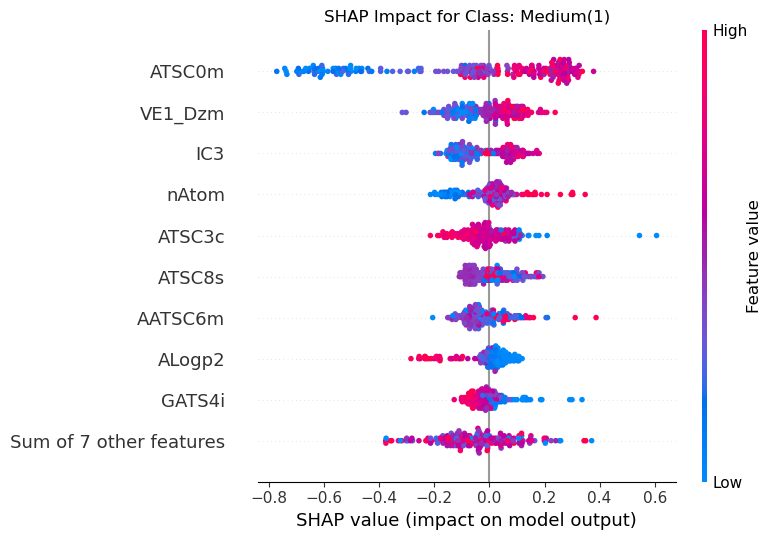

正在生成类别 High(2) 的分析图...


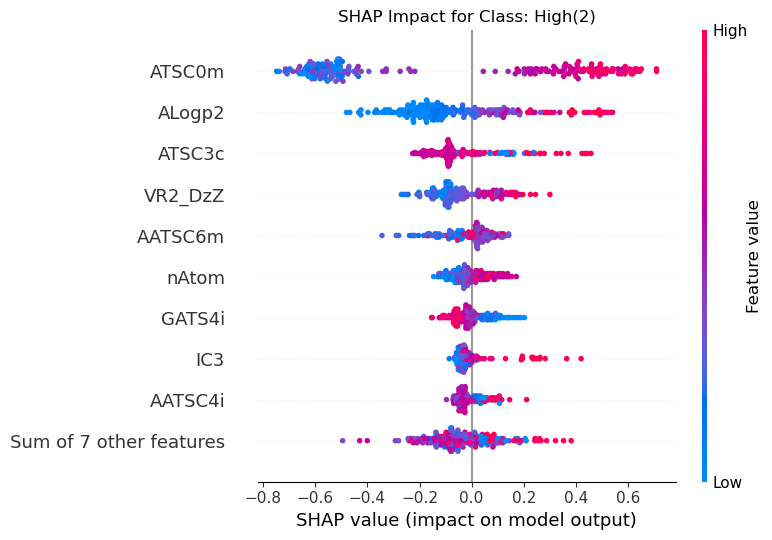


SHAP 分析全部完成！图片已保存至当前目录。


In [9]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 4. SHAP 可解释性分析 (优化版)
# ==========================================
print("\n" + "="*50)
print("正在进行 SHAP 解释分析...")
print("="*50)

# 1. 初始化 Explainer
# 注意：对于新版 XGBoost，TreeExplainer 效率最高
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test_scaled) # 推荐使用这种方式获取 Explanation 对象

# 获取原始的 shap_values 用于兼容旧版绘图函数
# 这里的处理能自动适配 list 结构或 numpy 数组结构
shap_v = shap_explanation.values

## 4.1 绘制综合 Summary Plot (Bar Chart)
# 展示每个特征对模型整体预测的平均影响幅度
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=300)
plt.show()
print("SHAP 综合柱状图已保存为 'shap_summary_bar.png'")
# 3. 循环绘制每个类别的 Beeswarm Plot
class_names = ['Low(0)', 'Medium(1)', 'High(2)'] # 建议根据业务逻辑命名

for i in range(len(class_names)):
    print(f"正在生成类别 {class_names[i]} 的分析图...")
    
    plt.figure(figsize=(10, 8))
    
    # 判断多分类索引逻辑
    # 如果 shap_v 是 (samples, features, classes)
    if len(shap_v.shape) == 3:
        current_sv = shap_explanation[:, :, i]
    # 如果是 list (旧版逻辑)
    elif isinstance(shap_v, list):
        current_sv = shap_explanation[i]
    else:
        current_sv = shap_explanation

    # 绘制蜂群图
    shap.plots.beeswarm(current_sv, show=False)
    
    plt.title(f"SHAP Impact for Class: {class_names[i]}")
    plt.tight_layout()
    # 动态命名文件名
    save_name = f'shap_beeswarm_class_{i}.png'
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print("\nSHAP 分析全部完成！图片已保存至当前目录。")

训练集大小: (1144, 16), 验证集大小: (143, 16), 测试集大小: (144, 16)

开始训练 TabNet...


C:\Users\yhh19\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.14861 | train_accuracy: 0.28497 | train_logloss: 10.50822| valid_accuracy: 0.3007  | valid_logloss: 10.424  |  0:00:00s
epoch 1  | loss: 1.25068 | train_accuracy: 0.28671 | train_logloss: 9.51536 | valid_accuracy: 0.32867 | valid_logloss: 8.68869 |  0:00:00s
epoch 2  | loss: 1.0497  | train_accuracy: 0.37413 | train_logloss: 7.68868 | valid_accuracy: 0.28671 | valid_logloss: 8.75772 |  0:00:01s
epoch 3  | loss: 1.07526 | train_accuracy: 0.3549  | train_logloss: 7.89504 | valid_accuracy: 0.34965 | valid_logloss: 7.87651 |  0:00:01s
epoch 4  | loss: 0.98905 | train_accuracy: 0.31206 | train_logloss: 8.42907 | valid_accuracy: 0.3007  | valid_logloss: 8.34255 |  0:00:02s
epoch 5  | loss: 0.96118 | train_accuracy: 0.33916 | train_logloss: 6.35373 | valid_accuracy: 0.33566 | valid_logloss: 6.78508 |  0:00:02s
epoch 6  | loss: 0.90696 | train_accuracy: 0.27885 | train_logloss: 6.65539 | valid_accuracy: 0.25874 | valid_logloss: 6.73883 |  0:00:03s
epoch 7  | loss: 0.81495 | 

C:\Users\yhh19\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet 模型评估结果
测试集准确率 (Accuracy): 0.5486
ROC AUC Score: 0.7700

分类报告:
              precision    recall  f1-score   support

           0       0.51      0.61      0.55        62
           1       0.61      0.47      0.53        43
           2       0.58      0.54      0.56        39

    accuracy                           0.55       144
   macro avg       0.57      0.54      0.55       144
weighted avg       0.56      0.55      0.55       144



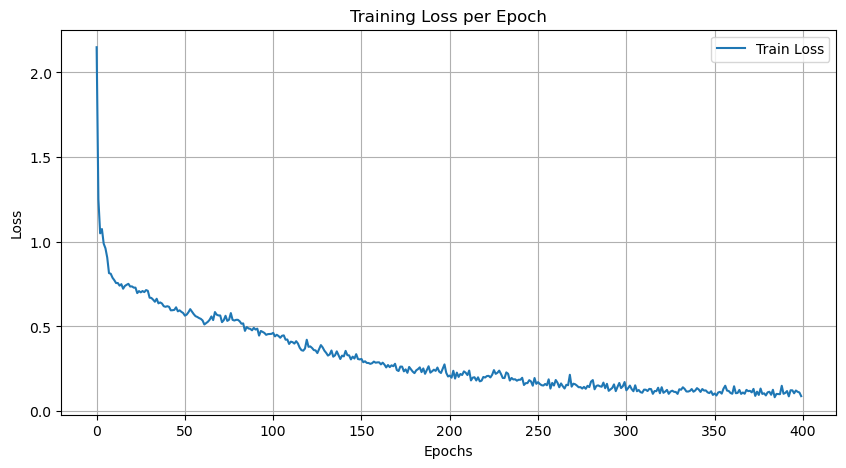

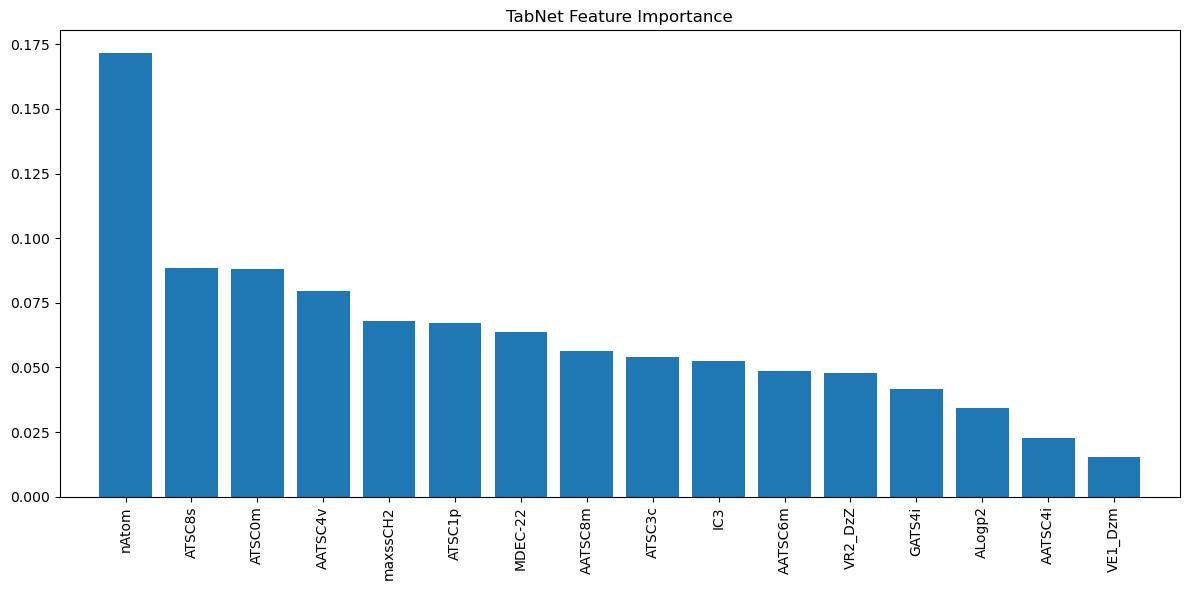

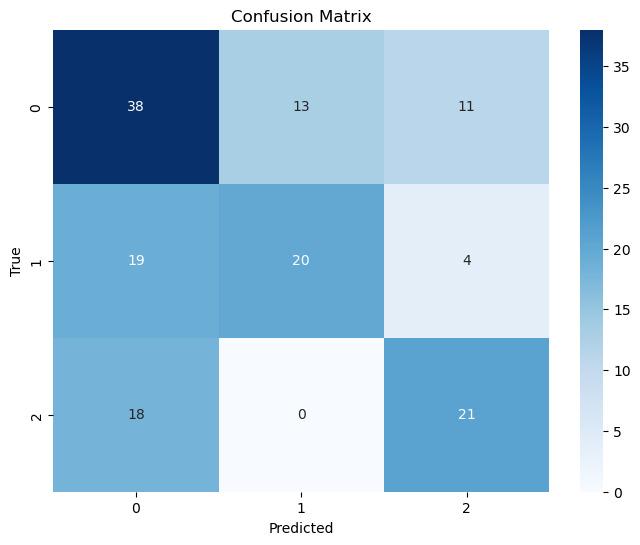

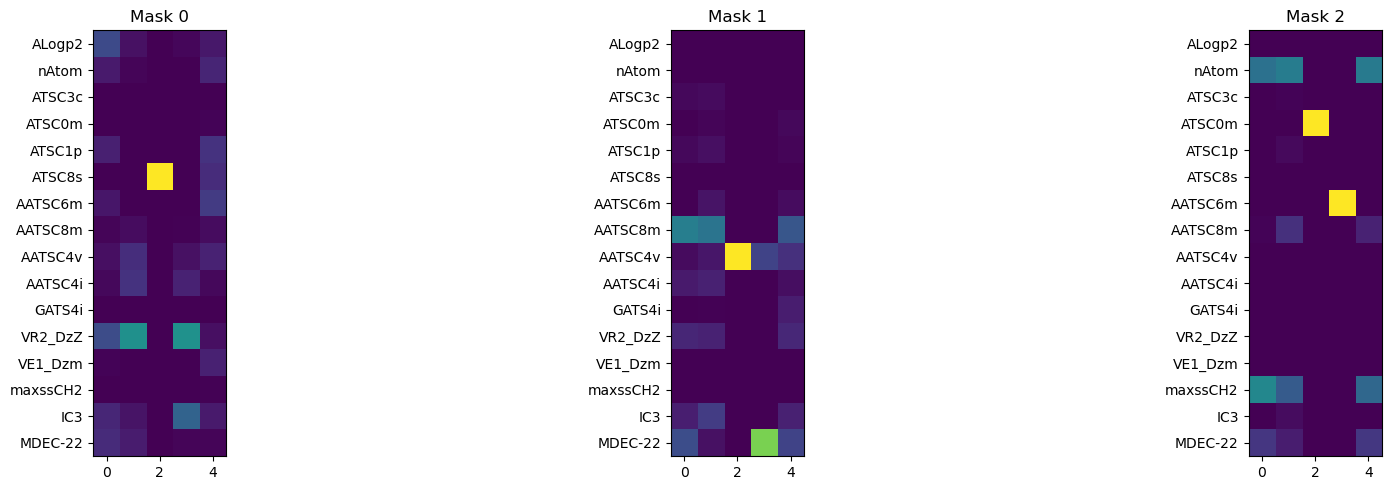


所有分析图片已保存。


In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import seaborn as sns

# 导入 TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

# ==========================================
# 1. 数据准备与预处理
# ==========================================
# 读取数据
file_path = "筛选后的特征.xlsx"
df = pd.read_excel(file_path)

# 剔除无关列
if 'name' in df.columns:
    df = df.drop(columns=['name'])

# 处理缺失值 (TabNet 不支持 NaN，必须填充)
df = df.fillna(df.mean())

# 分离特征和标签
target_col = 'target'
X = df.drop(columns=[target_col])
y = df[target_col]

# TabNet 需要 numpy 数组格式
X_values = X.values
y_values = y.values

# 确保标签是 0, 1, 2... 格式
le = LabelEncoder()
y_values = le.fit_transform(y_values)

# 划分数据集 (训练集, 验证集, 测试集)
# 80% 训练, 10% 验证, 10% 测试
X_train, X_temp, y_train, y_temp = train_test_split(X_values, y_values, test_size=0.2, random_state=42, stratify=y_values)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"训练集大小: {X_train.shape}, 验证集大小: {X_val.shape}, 测试集大小: {X_test.shape}")

# ==========================================
# 2. 构建与训练 TabNet 模型
# ==========================================
# 初始化模型
clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,    # 模型架构参数 (默认值通常效果不错)
    gamma=1.5, n_independent=2, n_shared=2,
    lambda_sparse=1e-4,           # 稀疏正则化系数，控制特征选择的稀疏性
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',           # 'sparsemax' 或 'entmax'
    device_name='auto',           # 自动检测 GPU
    verbose=1
)

# 训练模型
print("\n开始训练 TabNet...")
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy', 'logloss'],
    max_epochs=400,               # 最大迭代次数
    patience=500,                  # 早停策略 (20轮不提升则停止)
    batch_size=256, 
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# ==========================================
# 3. 模型评估
# ==========================================
# 预测
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

print("\n" + "="*50)
print("TabNet 模型评估结果")
print("="*50)

# 准确率
acc = accuracy_score(y_test, y_pred)
print(f"测试集准确率 (Accuracy): {acc:.4f}")

# 多分类 AUC
try:
    if len(np.unique(y_values)) > 2:
        auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc_score = roc_auc_score(y_test, y_proba[:, 1])
    print(f"ROC AUC Score: {auc_score:.4f}")
except Exception as e:
    print(f"AUC 计算跳过: {e}")

# 分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred))

# ==========================================
# 4. 可视化结果
# ==========================================
# 4.1 损失曲线
plt.figure(figsize=(10, 5))
plt.plot(clf.history['loss'], label='Train Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('tabnet_loss_curve.png')
plt.show()

# 4.2 特征重要性 (Feature Importance)
# TabNet 自带特征重要性属性
feat_importances = clf.feature_importances_
indices = np.argsort(feat_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("TabNet Feature Importance")
plt.bar(range(X.shape[1]), feat_importances[indices], align="center")
# 替换为真实的特征名
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.savefig('tabnet_feature_importance.png')
plt.show()

# 4.3 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('tabnet_confusion_matrix.png')
plt.show()

# 4.4 局部解释性 (Local Interpretability - Mask Visualization)
# TabNet 可以展示对于某个样本，模型关注了哪些特征
explain_matrix, masks = clf.explain(X_test[:]) # 解释前5个测试样本

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i in range(3):
    axs[i].imshow(masks[i][:5].T)
    axs[i].set_title(f"Mask {i}")
    axs[i].set_yticks(range(X.shape[1]))
    axs[i].set_yticklabels(X.columns)
plt.tight_layout()
plt.savefig('tabnet_masks.png')
plt.show()

print("\n所有分析图片已保存。")

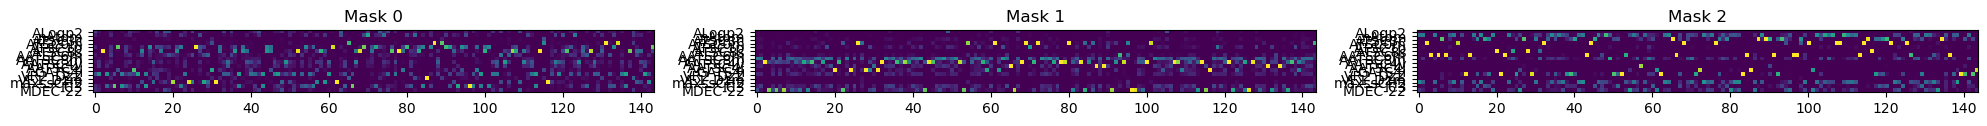


所有分析图片已保存。


In [4]:
# 4.4 局部解释性 (Local Interpretability - Mask Visualization)
# TabNet 可以展示对于某个样本，模型关注了哪些特征
explain_matrix, masks = clf.explain(X_test[:]) # 解释前5个测试样本

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i in range(3):
    axs[i].imshow(masks[i][:].T)
    axs[i].set_title(f"Mask {i}")
    axs[i].set_yticks(range(X.shape[1]))
    axs[i].set_yticklabels(X.columns)
plt.tight_layout()
plt.savefig('tabnet_masks.png')
plt.show()

print("\n所有分析图片已保存。")


正在进行 SHAP 分析 (这可能需要几分钟)...


D:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


  0%|          | 0/50 [00:00<?, ?it/s]

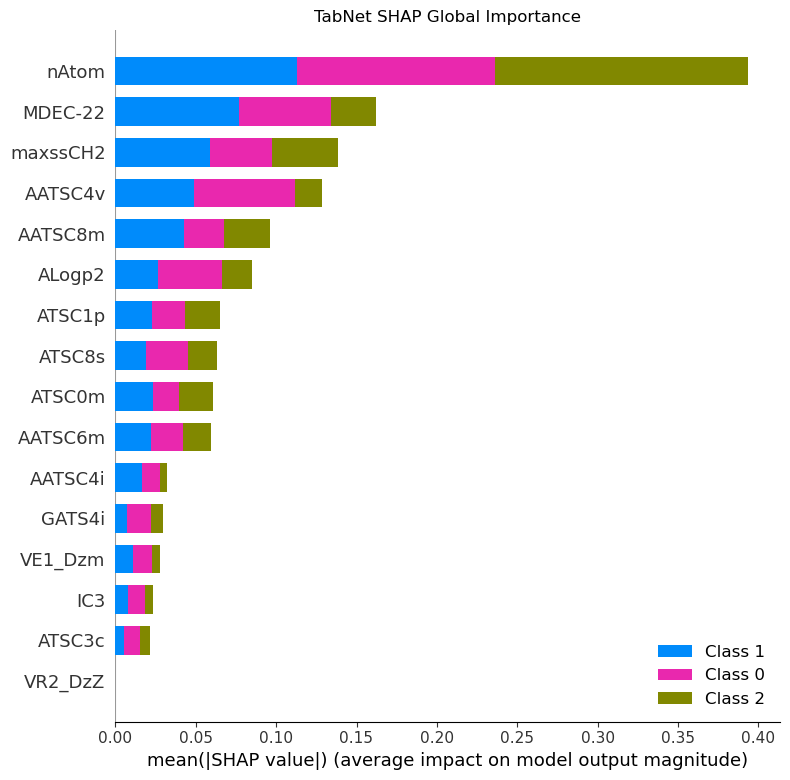

绘制类别 1 的特征影响图...


<Figure size 1000x800 with 0 Axes>

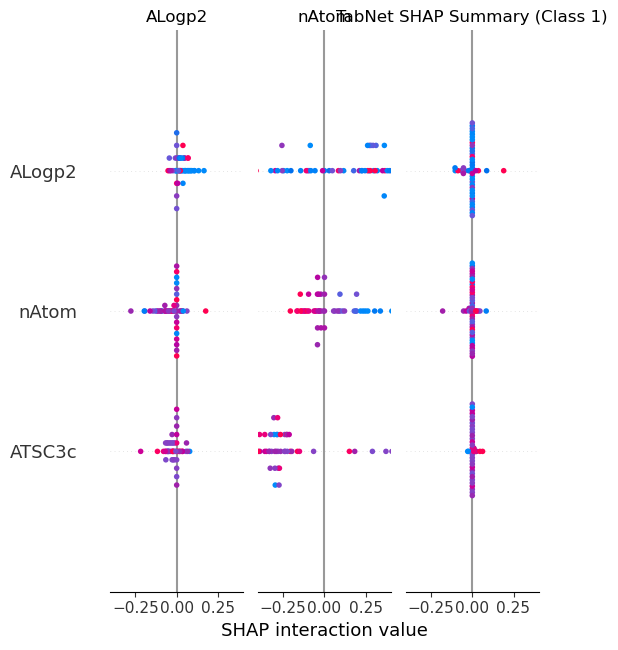

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [5]:
# ==========================================
# 3. 使用 SHAP 进行解释
# ==========================================
print("\n正在进行 SHAP 分析 (这可能需要几分钟)...")

#由于 TabNet 不是树模型，我们使用通用的 KernelExplainer 或 PermutationExplainer
# 这里使用 predict_proba 作为黑盒函数
# 注意：为了速度，我们只用 X_test 的一部分（例如前100个样本）来计算 SHAP 值
# 背景数据集 (background dataset) 也取一部分训练集，比如 100 个样本

# 定义预测函数 wrapper，确保输出格式正确
def predict_func(x):
    return clf.predict_proba(x)

# 使用 KernelExplainer (最通用，但较慢)
# background: 用于估算基线值的数据
background = shap.kmeans(X_train, 10) # 使用 K-means 聚类出 10 个代表性背景点以加速
explainer = shap.KernelExplainer(predict_func, background)

# 计算测试集前 50 个样本的 SHAP 值 (样本越多越慢)
X_test_sample = X_test[:50]
shap_values = explainer.shap_values(X_test_sample)

# ==========================================
# 4. SHAP 可视化
# ==========================================
feature_names = X.columns.tolist()

# 4.1 全局特征重要性 (Summary Plot - Bar)
plt.figure(figsize=(10, 8))
# shap_values 是一个 list，针对每个类别有一个数组。
# 对于多分类，通常展示所有类别的平均影响
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("TabNet SHAP Global Importance")
plt.tight_layout()
plt.savefig('tabnet_shap_bar.png', dpi=300)
plt.show()

# 4.2 针对特定类别 (例如类别 1) 的详细影响图 (Beeswarm Plot)
target_class = 1
print(f"绘制类别 {target_class} 的特征影响图...")
plt.figure(figsize=(10, 8))

# 检查 shap_values 是否为 list (多分类)
if isinstance(shap_values, list):
    # 多分类：取对应类别的 SHAP 值
    shap_values_target = shap_values[target_class]
else:
    # 二分类：通常只有一组值，直接使用
    shap_values_target = shap_values

shap.summary_plot(shap_values_target, X_test_sample, feature_names=feature_names, show=False)
plt.title(f"TabNet SHAP Summary (Class {target_class})")
plt.tight_layout()
plt.savefig(f'tabnet_shap_beeswarm_class_{target_class}.png', dpi=300)
plt.show()

# 4.3 单个样本解释 (Force Plot) - 交互式图表 (通常在 Notebook 中显示)
# 这里我们保存为 HTML
shap.initjs()
# 解释第一个测试样本，针对类别 1
force_plot = shap.force_plot(
    explainer.expected_value[target_class], 
    shap_values_target[0], 
    X_test_sample[0], 
    feature_names=feature_names,
    matplotlib=False # 设置为 False 以生成 JS 图
)
shap.save_html('tabnet_shap_force_plot.html', force_plot)
print("单个样本解释图已保存为 'tabnet_shap_force_plot.html'")

print("\n分析完成！")

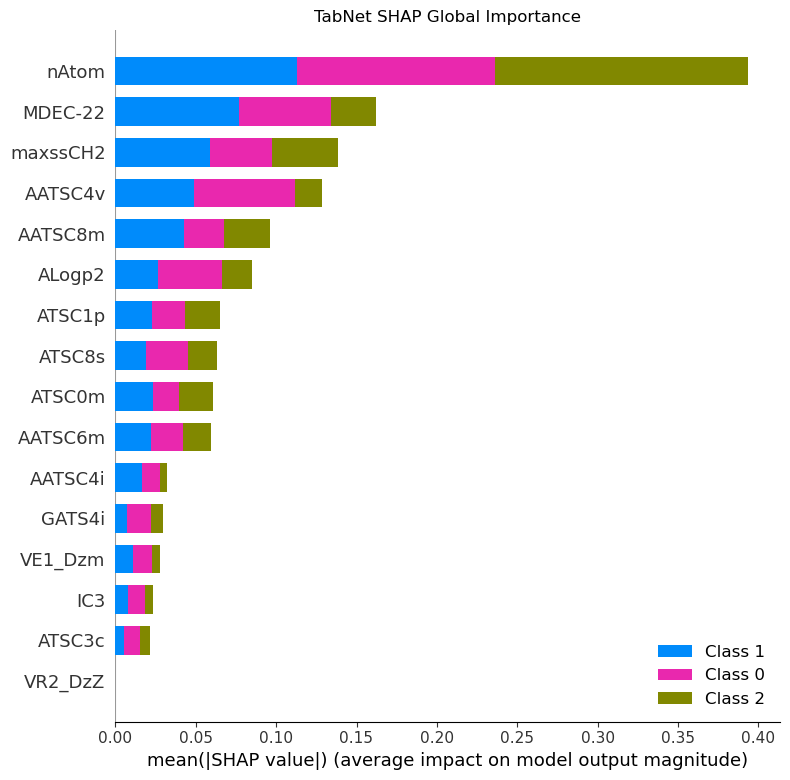

Plotting SHAP for Class 1...


<Figure size 1000x800 with 0 Axes>

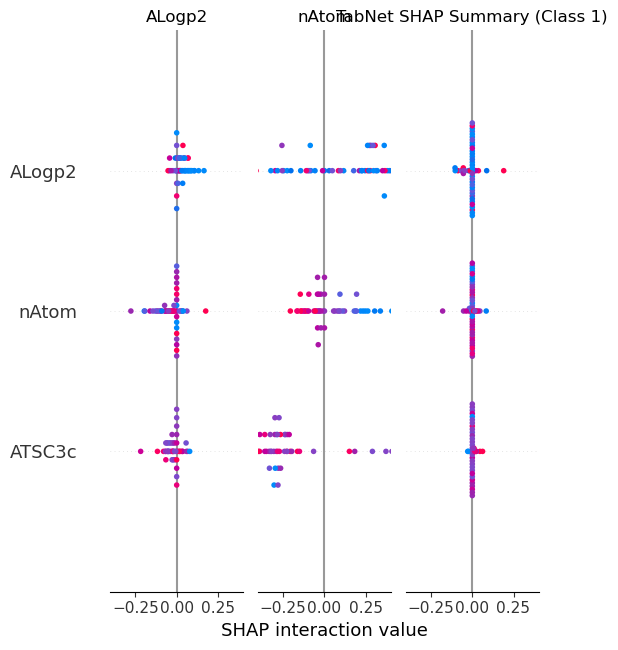

In [6]:
# ... (Training code remains the same) ...

# ==========================================
# 4. SHAP Visualization (Corrected)
# ==========================================
feature_names = X.columns.tolist()

# 4.1 Global Feature Importance (Bar Plot)
plt.figure(figsize=(10, 8))

# Check if shap_values is a list (Multi-class) or array (Binary/Regression)
if isinstance(shap_values, list):
    # For multi-class, summary_plot handles lists automatically for bar plots
    # It stacks the importance of each class
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type="bar", show=False)
else:
    # Binary/Regression case
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type="bar", show=False)

plt.title("TabNet SHAP Global Importance")
plt.tight_layout()
plt.savefig('tabnet_shap_bar.png', dpi=300)
plt.show()

# 4.2 Class-Specific Beeswarm Plot
target_class = 1
print(f"Plotting SHAP for Class {target_class}...")
plt.figure(figsize=(10, 8))

if isinstance(shap_values, list):
    # Extract the array for the specific class
    # This fixes "IndexError: too many indices"
    shap_data_for_class = shap_values[target_class]
    
    # Check if dimensions are correct (N_samples, N_features)
    # Sometimes KernelExplainer returns (N_samples, N_features, 1) or similar
    if len(shap_data_for_class.shape) == 3:
        shap_data_for_class = shap_data_for_class[:, :, 0]
        
    shap.summary_plot(shap_data_for_class, X_test_sample, feature_names=feature_names, show=False)
else:
    # Binary case
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)

plt.title(f"TabNet SHAP Summary (Class {target_class})")
plt.tight_layout()
plt.savefig(f'tabnet_shap_beeswarm_class_{target_class}.png', dpi=300)
plt.show()